# IML Project — Predicting Red Cards in Ligue 1

---
**Module:** IML — Introduction to Machine Learning  
**Dataset:** French Ligue 1 — Seasons 2019/20 to 2023/24  
**Source:** football-data.co.uk  

## 1. Data Loading & Exploratory Data Analysis (EDA)

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [77]:
dataset_path = 'Dataset/'

season_files = {
    '2019-20': 'L1-1920.csv',
    '2020-21': 'L1-2021.csv',
    '2021-22': 'L1-2122.csv',
    '2022-23': 'L1-2223.csv',
    '2023-24': 'L1-2324.csv'
}

dataframes = []

for season, filename in season_files.items():
    filepath = os.path.join(dataset_path, filename)
    dataset_season = pd.read_csv(filepath, encoding='unicode_escape')
    dataset_season['Season'] = season
    dataframes.append(dataset_season)
    print(f'Loaded {filename} - {dataset_season.shape[0]} rows, {dataset_season.shape[1]} columns')

dataset = pd.concat(dataframes, ignore_index=True)
print(f'\n--- Combined Dataset ---')
print(f'Total rows    : {dataset.shape[0]}')
print(f'Total columns : {dataset.shape[1]}')


Loaded L1-1920.csv - 279 rows, 106 columns
Loaded L1-2021.csv - 380 rows, 106 columns
Loaded L1-2122.csv - 380 rows, 106 columns
Loaded L1-2223.csv - 380 rows, 106 columns
Loaded L1-2324.csv - 306 rows, 106 columns

--- Combined Dataset ---
Total rows    : 1725
Total columns : 106


In [78]:
# firt 5 rows
dataset.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season
0,F1,09/08/2019,19:45,Monaco,Lyon,0,3,A,0,2,A,7,13,1,3,10,17,2,5,2,2,1,0,3.00,3.3,2.37,2.85,3.30,2.40,2.90,3.35,2.45,2.95,3.57,2.43,2.80,3.5,2.4,2.90,3.40,2.5,3.00,3.60,2.52,2.89,3.40,2.43,1.9,1.90,1.91,1.99,1.97,1.99,1.90,1.90,0.00,2.07,1.72,2.16,1.78,2.17,1.82,2.10,1.77,3.50,3.4,2.05,3.30,3.5,2.15,3.40,3.55,2.10,3.37,3.65,2.19,3.20,3.4,2.20,3.50,3.60,2.10,3.50,3.66,2.36,3.33,3.51,2.15,1.8,2.00,1.83,2.07,1.90,2.15,1.81,2.01,0.25,2.04,1.86,2.01,1.90,2.06,2.01,2.01,1.87,2019-20
1,F1,10/08/2019,16:30,Marseille,Reims,0,2,A,0,0,D,10,8,2,5,18,8,5,3,1,0,0,0,1.66,3.5,6.00,1.62,3.60,5.75,1.65,3.75,5.60,1.65,3.82,6.06,1.63,3.6,5.8,1.65,3.80,6.0,1.71,3.85,6.40,1.65,3.71,5.67,2.0,1.80,2.06,1.84,2.14,1.84,2.07,1.76,-0.75,1.87,2.03,1.87,2.05,1.89,2.08,1.86,2.02,1.66,3.4,6.00,1.67,3.6,5.75,1.73,3.60,5.10,1.78,3.39,5.70,1.70,3.5,5.25,1.73,3.60,5.50,1.80,3.70,6.15,1.73,3.49,5.45,2.1,1.72,2.16,1.76,2.24,1.81,2.08,1.75,-0.75,2.02,1.88,2.05,1.87,2.06,1.97,1.98,1.89,2019-20
2,F1,10/08/2019,19:00,Angers,Bordeaux,3,1,H,3,1,H,14,8,4,3,11,15,4,3,2,1,0,0,2.37,3.1,3.20,2.35,3.10,3.10,2.35,3.10,3.30,2.34,3.29,3.35,2.35,3.1,3.2,2.40,3.13,3.3,2.47,3.29,3.37,2.35,3.14,3.24,2.5,1.53,2.47,1.60,2.52,1.60,2.42,1.56,-0.25,2.02,1.88,2.01,1.91,2.05,1.91,2.00,1.87,2.05,3.2,3.80,2.05,3.2,4.00,2.05,3.10,4.10,2.10,3.24,4.08,2.00,3.2,4.00,2.10,3.13,4.10,2.14,3.30,4.20,2.08,3.16,3.96,2.5,1.53,2.67,1.52,2.72,1.56,2.59,1.49,-0.25,1.75,2.05,1.79,2.15,1.80,2.17,1.77,2.11,2019-20
3,F1,10/08/2019,19:00,Brest,Toulouse,1,1,D,1,0,H,16,13,5,3,11,14,4,7,0,0,0,0,2.37,3.2,3.10,2.40,3.10,3.00,2.40,3.20,3.10,2.42,3.33,3.17,2.30,3.3,3.1,2.38,3.25,3.2,2.46,3.42,3.22,2.38,3.23,3.09,2.1,1.72,2.17,1.76,2.20,1.76,2.14,1.71,-0.25,2.05,1.85,2.07,1.85,2.10,1.88,2.04,1.83,2.00,3.3,3.80,2.05,3.4,3.75,2.05,3.35,3.75,2.10,3.44,3.81,2.05,3.3,3.75,2.10,3.30,3.80,2.16,3.48,3.92,2.08,3.35,3.69,2.0,1.80,2.09,1.81,2.13,1.83,2.06,1.77,-0.50,2.10,1.80,2.10,1.83,2.12,1.83,2.08,1.79,2019-20
4,F1,10/08/2019,19:00,Dijon,St Etienne,1,2,A,1,2,A,15,12,7,4,17,10,12,5,0,2,0,0,4.00,3.2,2.05,3.60,3.25,2.05,3.55,3.35,2.10,3.69,3.46,2.13,3.60,3.3,2.1,3.70,3.40,2.1,4.00,3.46,2.20,3.57,3.34,2.11,2.0,1.80,2.08,1.82,2.16,1.83,2.05,1.77,0.25,2.07,1.83,2.09,1.83,2.11,1.86,2.05,1.82,3.80,3.4,2.00,3.70,3.4,2.05,3.75,3.40,2.05,3.84,3.47,2.08,3.75,3.4,2.00,3.90,3.40,2.05,3.92,3.48,2.14,3.73,3.37,2.06,2.0,1.80,2.04,1.85,2.10,1.92,2.03,1.79,0.25,2.07,1.72,2.14,1.79,2.16,1.82,2.09,1.79,2019-20


In [79]:
# All colum names
print(dataset.columns.tolist())

['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA', 'Season']


In [80]:
# Define columns we want to keep (our ...)
columns_to_keep = ['HomeTeam',  'AwayTeam', 'Season',  # match info
    'HS', 'AS',                          # shots
    'HST', 'AST',                        # shots on target
    'HF', 'AF',                          # fouls
    'HC', 'AC',                          # corners
    'B365H', 'B365D', 'B365A',           # betting odds
    'HR', 'AR'     ]                     # red cards (to create target variable)

# Keep only those columns
dataset = dataset[columns_to_keep]

print(f'Columns kept  : {dataset.shape[1]}')
print(f'Rows          : {dataset.shape[0]}')
print(f'\nColumn names  : {dataset.columns.tolist()}')

Columns kept  : 16
Rows          : 1725

Column names  : ['HomeTeam', 'AwayTeam', 'Season', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'B365H', 'B365D', 'B365A', 'HR', 'AR']


In [81]:
# Create the target variable
# If HR (Home Red Cards) + AR (Away Red Cards) >= 1, then RedCard = 1, else 0
dataset['RedCard'] = ((dataset['HR'] + dataset['AR']) >= 1).astype(int)

# Now drop HR and AR since we no longer need them
dataset = dataset.drop(columns=['HR', 'AR'])

# Check the result
print('RedCard distribution:')
print(dataset['RedCard'].value_counts())
print(f'\nTotal matches with red card    : {dataset["RedCard"].sum()}')
print(f'Total matches without red card : {(dataset["RedCard"] == 0).sum()}')
print(f'Red card rate                  : {dataset["RedCard"].mean()*100:.1f}%')

RedCard distribution:
RedCard
0    1358
1     367
Name: count, dtype: int64

Total matches with red card    : 367
Total matches without red card : 1358
Red card rate                  : 21.3%


In [82]:
# Counting miising values per columns
dataset.isnull().sum()

HomeTeam    0
AwayTeam    0
Season      0
HS          0
AS          0
HST         0
AST         0
HF          0
AF          0
HC          0
AC          0
B365H       2
B365D       2
B365A       2
RedCard     0
dtype: int64

In [83]:
# Detect missing value percentage

100 * dataset.isnull().sum() / len(dataset)

HomeTeam    0.000000
AwayTeam    0.000000
Season      0.000000
HS          0.000000
AS          0.000000
HST         0.000000
AST         0.000000
HF          0.000000
AF          0.000000
HC          0.000000
AC          0.000000
B365H       0.115942
B365D       0.115942
B365A       0.115942
RedCard     0.000000
dtype: float64

In [84]:
# Count missing values per column
missing = dataset.isnull().sum()
missing_pct = (missing / len(dataset)) * 100

# Combine into a readable table
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

# Show only columns that have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
print()
print(missing_df)

Columns with missing values: 3

       Missing Count  Missing %
B365H              2       0.12
B365D              2       0.12
B365A              2       0.12


In [85]:
# Drop rows with missing values
dataset = dataset.dropna()

# Confirm no missing values remain
print(f'Missing values remaining : {dataset.isnull().sum().sum()}')
print(f'Rows remaining           : {len(dataset)}')

Missing values remaining : 0
Rows remaining           : 1723


In [86]:
# Check for duplicate rows
duplicates = dataset.duplicated().sum()

print(f'Number of duplicate rows : {duplicates}')

Number of duplicate rows : 0


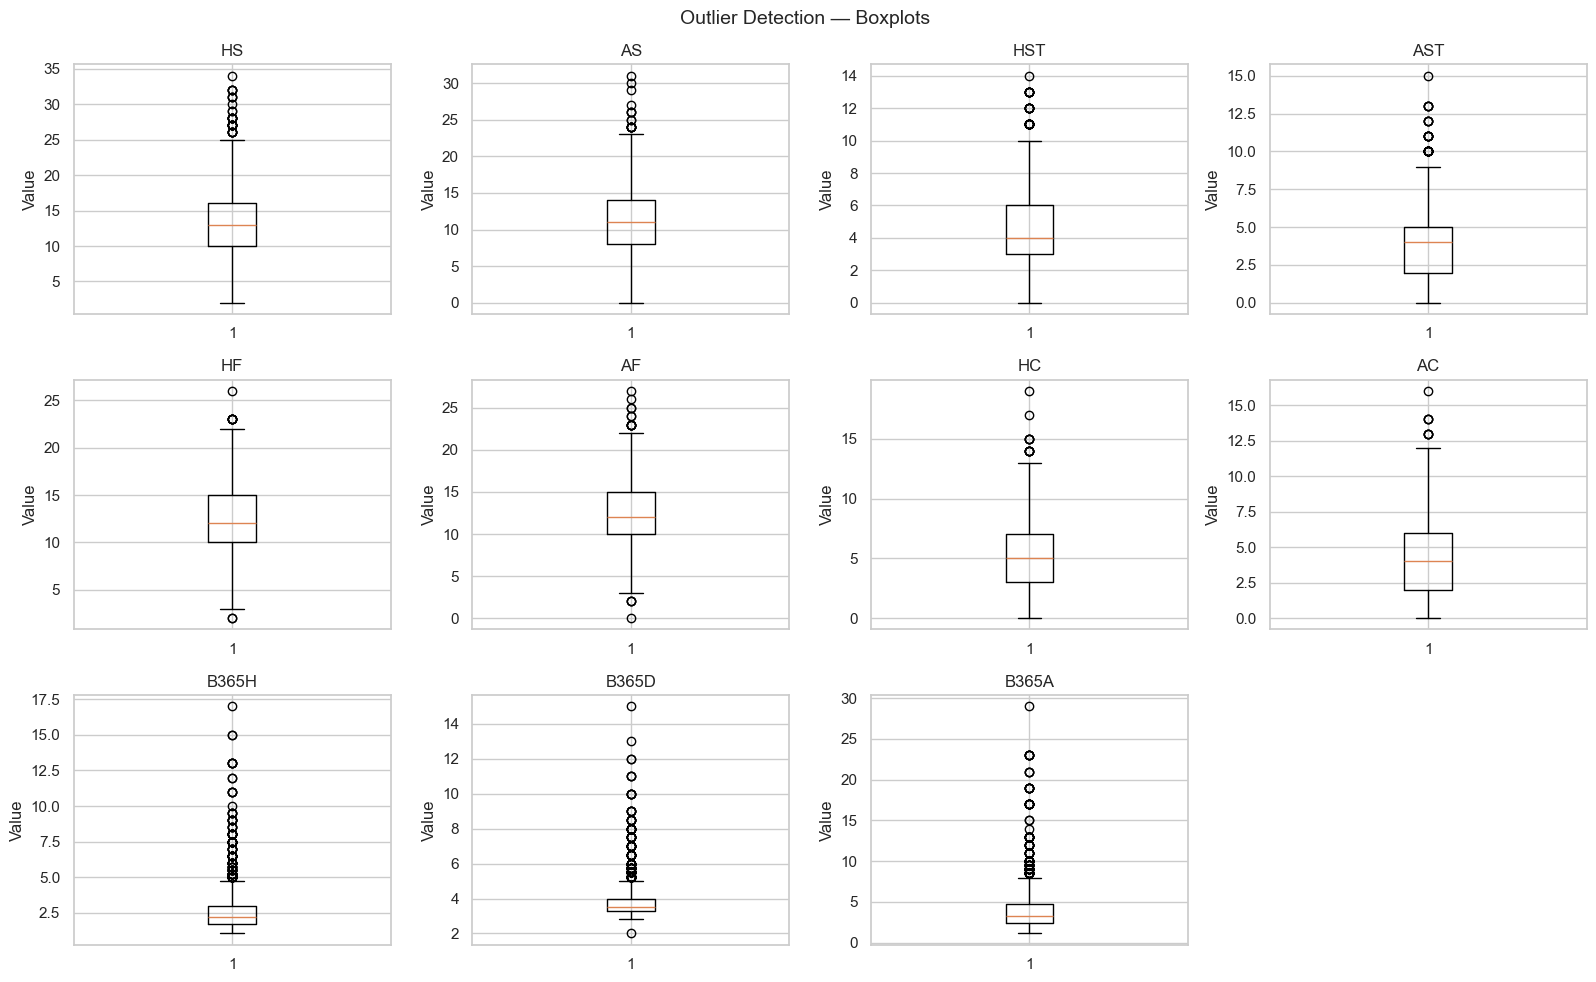

In [87]:
# Visualise outliers using boxplots
numeric_cols = ['HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'B365H', 'B365D', 'B365A']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(dataset[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection — Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

In [88]:
# Outlier check conclusion
print('Outliers identified in numeric columns.')
print('Decision: Retained — all values represent real football match events.')
print(f'Dataset shape remains: {dataset.shape}')

Outliers identified in numeric columns.
Decision: Retained — all values represent real football match events.
Dataset shape remains: (1723, 15)


In [89]:
from sklearn.model_selection import train_test_split

# Separate features and target variable 
x = dataset.drop(columns=['RedCard']) # features
y = dataset['RedCard'] # target

#Split into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2,      #20% for testing
    random_state=42,    #ensures same split every time you run 
    stratify=y          #keeps same class ration in both splits 
)

print(f'Total rows: {len(dataset)}')
print(f'Training rows    : {len(x_train)} ({len(x_train)/len(dataset)*100:.1f}%)')
print(f'Testing rows     : {len(x_test)} ({len(x_test)/len(dataset)*100:.1f}%)')
print(f'\nTraining RedCard distribution:')
print(y_train.value_counts())
print(f'\nTesting RedCard distribution:')
print(y_test.value_counts())





Total rows: 1723
Training rows    : 1378 (80.0%)
Testing rows     : 345 (20.0%)

Training RedCard distribution:
RedCard
0    1086
1     292
Name: count, dtype: int64

Testing RedCard distribution:
RedCard
0    272
1     73
Name: count, dtype: int64


In [90]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder for each categorical column
le_home = LabelEncoder()
le_away = LabelEncoder()
le_season = LabelEncoder()

# Encode each categorical column
x_train['HomeTeam'] = le_home.fit_transform(x_train['HomeTeam'])
x_test['HomeTeam'] = le_home.transform(x_test['HomeTeam'])

x_train['AwayTeam'] = le_away.fit_transform(x_train['AwayTeam'])
x_test['AwayTeam'] = le_away.transform(x_test['AwayTeam'])

x_train['Season'] = le_season.fit_transform(x_train['Season'])
x_test['Season'] = le_season.transform(x_test['Season'])

# Check the result
print('Encoding done!')
print()
print(x_train[['HomeTeam', 'AwayTeam', 'Season']].head(10))

Encoding done!

      HomeTeam  AwayTeam  Season
1320         3        26       3
703          5         2       2
88          22        21       0
212          1        25       0
247          5        23       0
570         14        22       1
1160        20        26       3
624          7        14       1
781          4        20       2
1054        21         6       3


RedCard
0    1358
1     365
Name: count, dtype: int64


Text(0, 0.5, 'Count')

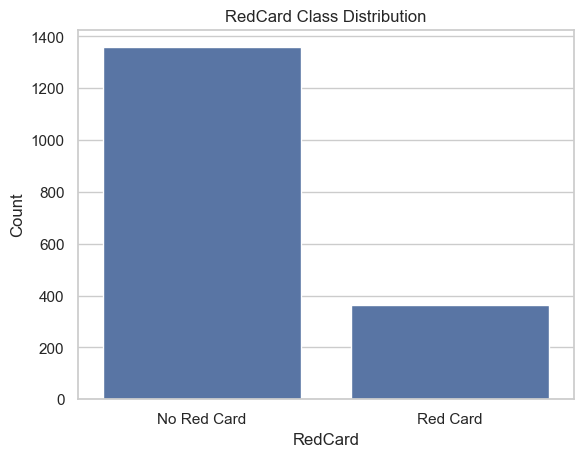

In [91]:
print(dataset['RedCard'].value_counts())

import seaborn as sns
sns.countplot(x = dataset['RedCard'])
plt.xticks([0, 1], ['No Red Card', 'Red Card'])
plt.title('RedCard Class Distribution')
plt.xlabel('RedCard')
plt.ylabel('Count')

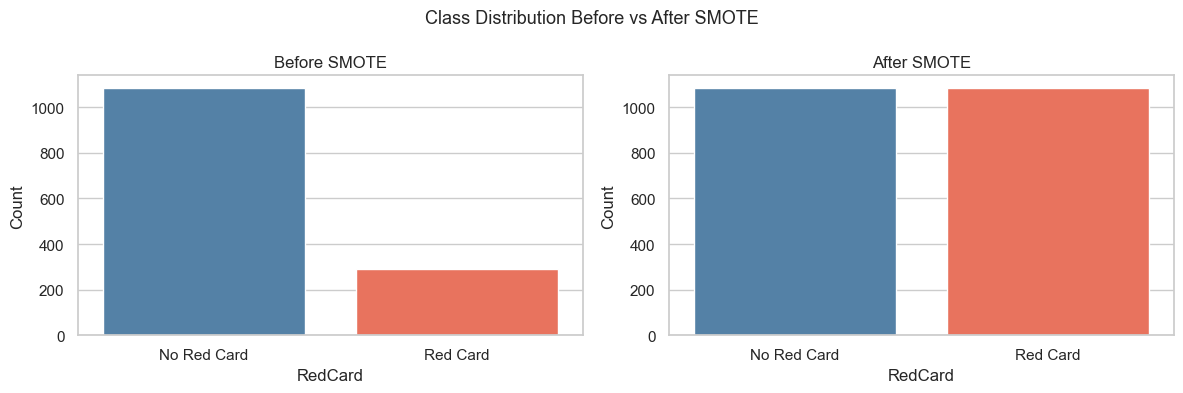


Training rows before SMOTE : 1378
Training rows after SMOTE  : 2172


In [92]:
from imblearn.over_sampling import SMOTE

#Create smote object
smote = SMOTE(random_state=42)

#Apply smote on training data ONLY
x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)



fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0], hue=y_train, palette=['steelblue', 'tomato'], legend=False)
axes[0].set_title('Before SMOTE')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Red Card', 'Red Card'])
axes[0].set_ylabel('Count')

# After SMOTE
sns.countplot(x=y_train_balanced, ax=axes[1], hue=y_train_balanced, palette=['steelblue', 'tomato'], legend=False)
axes[1].set_title('After SMOTE')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Red Card', 'Red Card'])
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nTraining rows before SMOTE : {len(x_train)}')
print(f'Training rows after SMOTE  : {len(x_train_balanced)}')


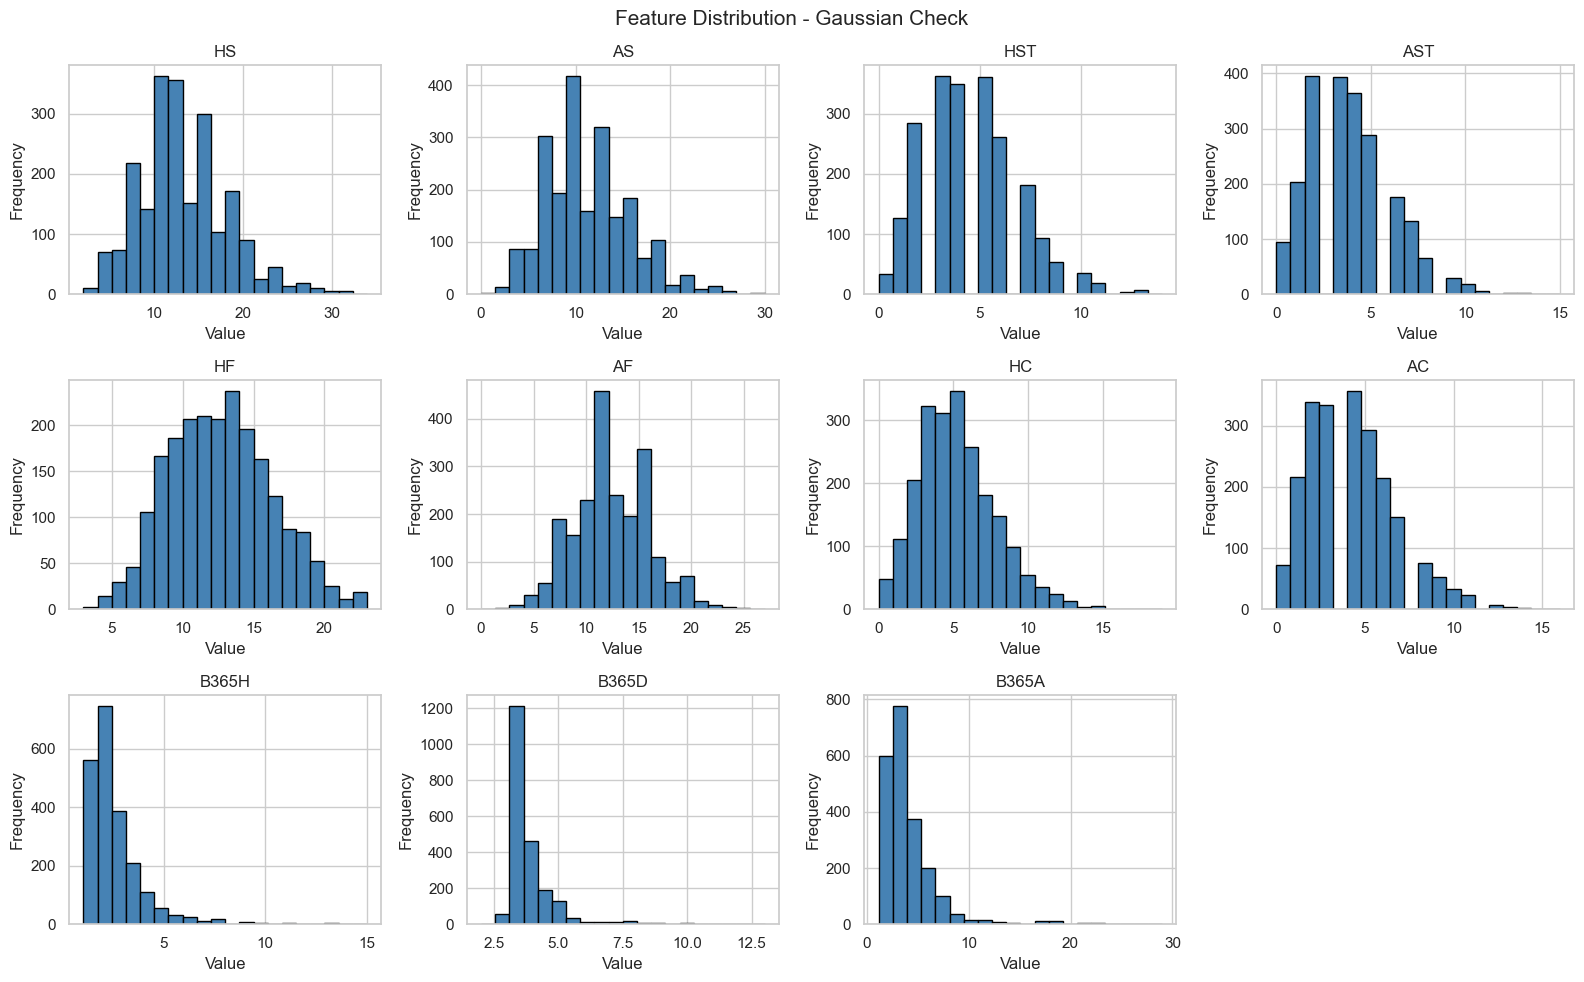

In [93]:
#Check distrinution to choose between Normalization and Standardization
numeric_cols = ['HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'B365H', 'B365D', 'B365A']

fig, axes = plt.subplots(3,4, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(x_train_balanced[col], bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

#Hide unused subplot
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distribution - Gaussian Check', fontsize=15)
plt.tight_layout()
plt.show()

In [94]:
from sklearn.preprocessing import MinMaxScaler

#Create the scaler
scaler = MinMaxScaler()

#Fit on training data only, transform both train and test 
x_train_scaled = scaler.fit_transform(x_train_balanced)
x_test_scaled = scaler.transform(x_test)

#Convert back to dataframe so it's readable
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train_balanced.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

print('Normalization done!')
print()
print('x_train_scaled sample:')
print(x_train_scaled.head())
print()
print(f'Min value in X_train_scaled: {x_train_scaled.min().min():.2f}')
print(f'Max value in X_train_scaled: {x_train_scaled.max().max():.2f}')

Normalization done!

x_train_scaled sample:
   HomeTeam  AwayTeam  Season       HS        AS       HST       AST    HF  \
0  0.115385  1.000000    0.75  0.34375  0.466667  0.357143  0.133333  0.20   
1  0.192308  0.076923    0.50  0.31250  0.266667  0.428571  0.133333  0.80   
2  0.846154  0.807692    0.00  0.50000  0.433333  0.214286  0.466667  0.50   
3  0.038462  0.961538    0.00  0.21875  0.400000  0.285714  0.066667  0.55   
4  0.192308  0.884615    0.00  0.25000  0.366667  0.214286  0.266667  0.40   

         AF        HC      AC     B365H     B365D     B365A  
0  0.555556  0.210526  0.3125  0.056671  0.145455  0.109195  
1  0.333333  0.263158  0.1875  0.110473  0.127273  0.055316  
2  0.703704  0.263158  0.1875  0.081779  0.100000  0.087644  
3  0.555556  0.421053  0.2500  0.071019  0.118182  0.094828  
4  0.407407  0.000000  0.3125  0.129842  0.109091  0.049928  

Min value in X_train_scaled: 0.00
Max value in X_train_scaled: 1.00


## **2-MODEL BUILDING**

## Model 1: K-Nearest Neighbors (KNN)

In [95]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

#Build base KNN model with default
knn = KNeighborsClassifier()
knn.fit(x_train_scaled, y_train_balanced)
y_pred_knn = knn.predict(x_test_scaled)

#Evaluate
acc_knn = accuracy_score(y_test, y_pred_knn) * 100
print("KNN - Accuracy: {:.3f}.".format(acc_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['No Red Card', 'Red Card']))

KNN - Accuracy: 55.072.

Classification Report:
              precision    recall  f1-score   support

 No Red Card       0.80      0.57      0.67       272
    Red Card       0.23      0.47      0.30        73

    accuracy                           0.55       345
   macro avg       0.51      0.52      0.49       345
weighted avg       0.68      0.55      0.59       345



[[156 116]
 [ 39  34]]


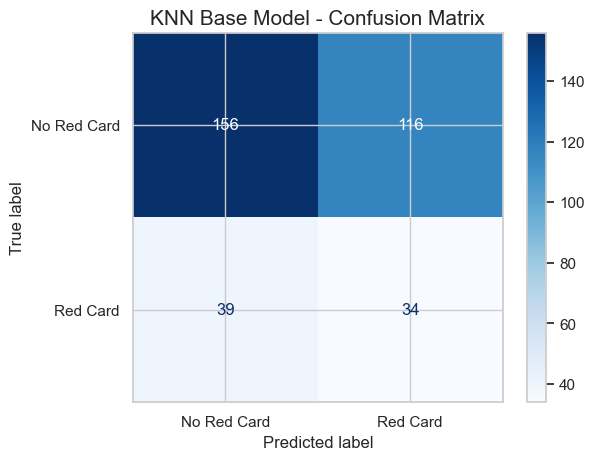

In [96]:
#confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

#compute
cm_knn = confusion_matrix(y_test, y_pred_knn)

#Display
print(cm_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Red Card', 'Red Card'])
disp.plot(cmap='Blues')
plt.title('KNN Base Model - Confusion Matrix', fontsize=15)
plt.show()



In [97]:
## KNN HP TUNING
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score
from numpy import arange

#Define parameters
parameters = {
    'n_neighbors': arange(1, 31, 1),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': arange(10, 51,10),
    'p': (1, 2)
}

knn_grid = GridSearchCV(estimator=knn, param_grid= parameters, scoring='accuracy', cv=10, n_jobs=1)

#Fit the grid
knn_grid.fit(x_train_scaled,y_train_balanced)

print("\nBest Parameters: ", knn_grid.best_params_)
print("Best Scores: ", knn_grid.best_score_) 

best_knn_model = knn_grid.best_estimator_

y_pred_knn_tuned = best_knn_model.predict(x_test_scaled)

#Get the accuracy score
knn_acc = accuracy_score(y_test, y_pred_knn_tuned)*100
knn_pre = precision_score(y_test, y_pred_knn_tuned, average = 'weighted')
knn_recall = recall_score(y_test, y_pred_knn_tuned, average = 'weighted')
knn_f1_ = f1_score(y_test, y_pred_knn_tuned, average = 'weighted')

print("\nKNN tuned - Accuracy: {:.3f}.".format(knn_acc))
print("KNN Tuned - Precision: {:.3f}.".format(knn_pre))
print("KNN Tuned - Recall: {:.3f}.".format(knn_recall))
print("KNN Tuned - F1_Score: {:.3f}.".format(knn_f1_))
print ('\n Clasification Report:\n', classification_report(y_test, y_pred_knn_tuned, target_names=['No Red Card', 'Red Card']))
print()



Best Parameters:  {'algorithm': 'auto', 'leaf_size': np.int64(10), 'n_neighbors': np.int64(2), 'p': 1, 'weights': 'uniform'}
Best Scores:  0.8476176383545427

KNN tuned - Accuracy: 70.145.
KNN Tuned - Precision: 0.694.
KNN Tuned - Recall: 0.701.
KNN Tuned - F1_Score: 0.698.

 Clasification Report:
               precision    recall  f1-score   support

 No Red Card       0.81      0.82      0.81       272
    Red Card       0.28      0.26      0.27        73

    accuracy                           0.70       345
   macro avg       0.54      0.54      0.54       345
weighted avg       0.69      0.70      0.70       345




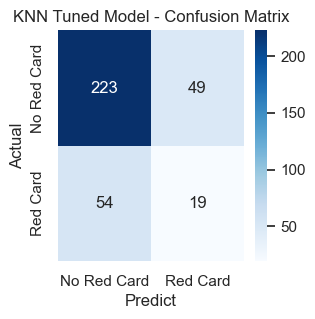

In [98]:
#Confusion matrix for tunned KNN
cm_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned)

plt.figure(figsize=(3,3))
sns.heatmap(cm_knn_tuned, annot= True, fmt='d', cmap='Blues',
            xticklabels=['No Red Card', 'Red Card'],
            yticklabels=['No Red Card', 'Red Card'],
            linewidth=0)
plt.title('KNN Tuned Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

## Model 2: Logistic Regression

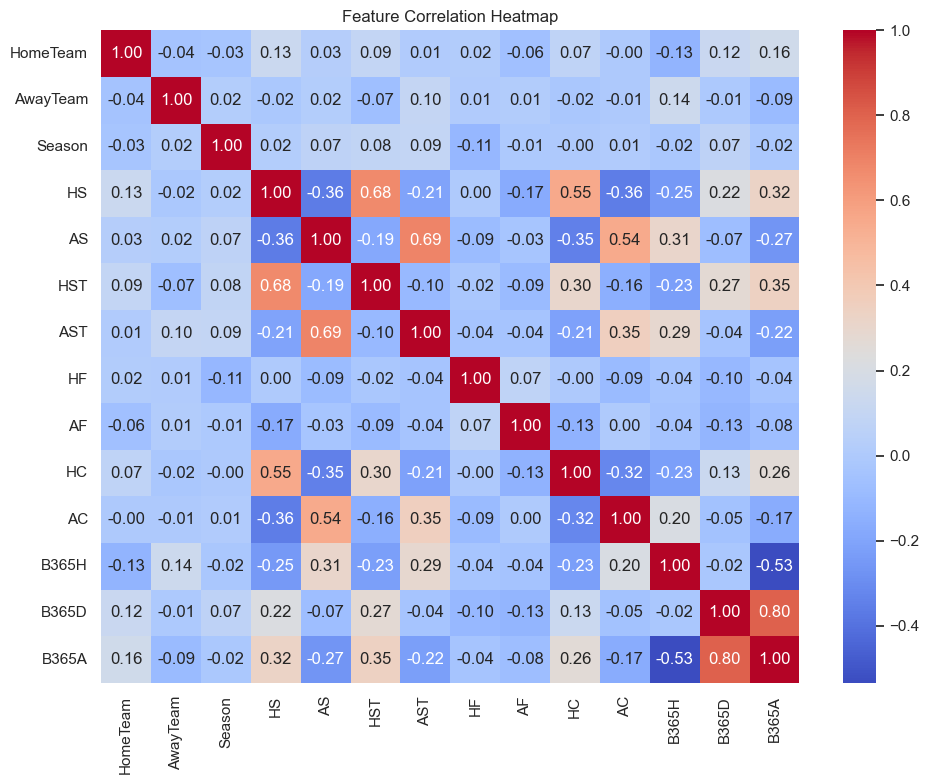

In [99]:
# Correlation heatmap of training features
plt.figure(figsize=(10, 8))
sns.heatmap(x_train_scaled.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

logreg = LogisticRegression(max_iter=1000)
rfe = RFE(logreg, n_features_to_select = 10, step = 1)
rfe = rfe.fit(x_train_scaled, y_train_balanced.values.ravel())
print(rfe.support_) 
print(rfe.ranking_)

[False  True  True  True  True  True  True False False  True  True  True
 False  True]
[5 1 1 1 1 1 1 2 4 1 1 1 3 1]


In [101]:
#Logistic Regression Model 
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(x_train_scaled, y_train_balanced)

log_reg.get_params()




{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [102]:
#Predicting the Test set results
y_pred_lr = log_reg.predict(x_test_scaled)

#Model Evaluation
print ('Accuracy: ', accuracy_score(y_test, y_pred_lr)*100,'%')
print ('Precision: ', precision_score(y_test, y_pred_lr, average = 'weighted')) 
print ('Recall: ', recall_score(y_test, y_pred_lr, average = 'weighted'))
print ('F1 Score: ', f1_score(y_test, y_pred_lr, average = 'weighted'))
print ('\n Classification Report:\n', classification_report(y_test,y_pred_lr))

Accuracy:  51.01449275362319 %
Precision:  0.6255163359087007
Recall:  0.5101449275362319
F1 Score:  0.5527850419137436

 Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.57      0.65       272
           1       0.16      0.30      0.21        73

    accuracy                           0.51       345
   macro avg       0.45      0.43      0.43       345
weighted avg       0.63      0.51      0.55       345



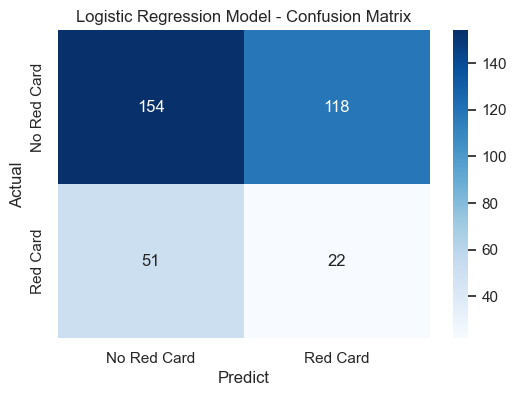

In [103]:
#Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot= True, fmt='d', cmap='Blues',
            xticklabels=['No Red Card', 'Red Card'],
            yticklabels=['No Red Card', 'Red Card'],
            linewidth=0)
plt.title('Logistic Regression Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

In [114]:
#HYPER PARAMETER TUNING
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)

parameters =  dict()
parameters['penalty'] = ['l1', 'l2']
parameters['C'] = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 7, 10]
parameters['solver'] = ['liblinear', 'saga']
parameters['random_state'] = arange(0, 50, 1)

## Building Grid Search algorithm with cross-validation and acc score.
grid_search_LR = GridSearchCV(estimator = log_reg, param_grid = parameters, scoring = 'accuracy', cv = skf)

## Lastly, finding the best parameters
grid_search_LR.fit(x_train_scaled, y_train_balanced)

print("Best Parameters: ", grid_search_LR.best_params_)
print("Best score: ", grid_search_LR.best_score_)

best_lr_model = grid_search_LR.best_estimator_
y_pred_lr_tuned = best_lr_model.predict(x_test_scaled)

#Get accuracy score
lr_acc = accuracy_score(y_test, y_pred_lr_tuned,)*100
lr_pre = precision_score(y_test, y_pred_lr_tuned,  average='weighted')
lr_recall = recall_score(y_test, y_pred_lr_tuned,  average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr_tuned,  average='weighted')

print("\nLR - Accuracy: {:.3f}%.".format(lr_acc))
print("LR - Precision: {:.3f}.".format(lr_pre))
print("LR - Recall: {:.3f}.".format(lr_recall))
print("LR - F1 Score: {:.3f}.".format(lr_f1))
print ('\n Classification Report:\n', classification_report(y_test, y_pred_lr_tuned, target_names=['No Red Card', 'Red Card']))

Best Parameters:  {'C': 10, 'penalty': 'l2', 'random_state': np.int64(0), 'solver': 'liblinear'}
Best score:  0.6058931860036832

LR - Accuracy: 51.014%.
LR - Precision: 0.626.
LR - Recall: 0.510.
LR - F1 Score: 0.553.

 Classification Report:
               precision    recall  f1-score   support

 No Red Card       0.75      0.57      0.65       272
    Red Card       0.16      0.30      0.21        73

    accuracy                           0.51       345
   macro avg       0.45      0.43      0.43       345
weighted avg       0.63      0.51      0.55       345



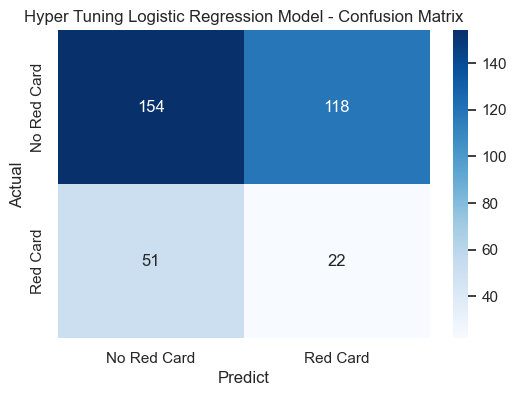

In [105]:
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr_tuned, annot= True, fmt='d', cmap='Blues',
            xticklabels=['No Red Card', 'Red Card'],
            yticklabels=['No Red Card', 'Red Card'],
            linewidth=0)
plt.title('Hyper Tuning Logistic Regression Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

## Model 3: Random Forest

In [106]:
from sklearn.ensemble import RandomForestClassifier

#Base model with default parameters
rf = RandomForestClassifier()
rf.fit(x_train_scaled, y_train_balanced)

y_pred_rf = rf.predict(x_test_scaled)

#Evaluate
acc_rf = accuracy_score(y_test, y_pred_rf) * 100
print("Random Forest - Accuracy: {:.3f}%".format(acc_rf))
print ("Random Forest - Precision:  {:.3f}".format(precision_score(y_test, y_pred_rf, average = 'weighted'))) 
print ("Random Forest - Recall: {:.3}" .format(recall_score(y_test, y_pred_rf, average = 'weighted')))
print ("Random Forest - F1 Score: {:.3}" .format(f1_score(y_test, y_pred_rf, average = 'weighted')))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Red Card', 'Red Card']))


Random Forest - Accuracy: 72.754%
Random Forest - Precision:  0.672
Random Forest - Recall: 0.728
Random Forest - F1 Score: 0.694

Classification Report:
              precision    recall  f1-score   support

 No Red Card       0.79      0.89      0.84       272
    Red Card       0.23      0.12      0.16        73

    accuracy                           0.73       345
   macro avg       0.51      0.51      0.50       345
weighted avg       0.67      0.73      0.69       345



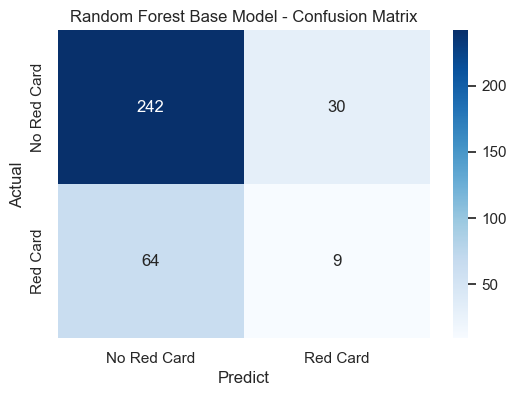

In [107]:
#Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot= True, fmt='d', cmap='Blues',
            xticklabels=['No Red Card', 'Red Card'],
            yticklabels=['No Red Card', 'Red Card'],
            linewidth=0)
plt.title('Random Forest Base Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

In [108]:
# HP Tuning for Random Forest
from sklearn.model_selection import RandomizedSearchCV


# 1. Refined parameter grid
param_dist = {
    'n_estimators': [50, 100, 200],         # Reduced high end to save time, added mid-range
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]                    # Added bootstrap options
}

# 2. Build RandomizedSearchCV 
# Optimization: Changed scoring to 'f1_weighted' to better handle class importance
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42), 
    param_distributions=param_dist, 
    n_iter=50,           
    cv=3,                # Increased to 5-fold for better reliability
    verbose=1, 
    random_state=42, 
    n_jobs=-1,
    scoring='f1_weighted' 
)

# 3. Fit on the BALANCED training data
rf_random.fit(x_train_scaled, y_train_balanced)

print("Best Parameters: ", rf_random.best_params_)
print("Best CV Score (F1): ", rf_random.best_score_)

# 4. Predict using the best model
best_rf_model = rf_random.best_estimator_
y_pred_rf_tuned = best_rf_model.predict(x_test_scaled)

# 5. Evaluate with correct labels
rf_acc = accuracy_score(y_test, y_pred_rf_tuned)*100
rf_pre = precision_score(y_test, y_pred_rf_tuned,  average='weighted')
rf_recall = recall_score(y_test, y_pred_rf_tuned,  average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf_tuned,  average='weighted')

print("\nRF (Tuned) - Accuracy: {:.3f} %".format(rf_acc))
print("RF (Tuned) - Precision: {:.3f}".format(rf_pre))
print("RF (Tuned) - Recall: {:.3f}".format(rf_recall))
print("RF (Tuned) - F1 Score: {:.3f}".format(rf_f1))

print('\nClassification Report:\n', classification_report(y_test, y_pred_rf_tuned, target_names=['No Red Card', 'Red Card']))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters:  {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}
Best CV Score (F1):  0.850366920341393

RF (Tuned) - Accuracy: 73.333 %
RF (Tuned) - Precision: 0.684
RF (Tuned) - Recall: 0.733
RF (Tuned) - F1 Score: 0.703

Classification Report:
               precision    recall  f1-score   support

 No Red Card       0.80      0.89      0.84       272
    Red Card       0.27      0.15      0.19        73

    accuracy                           0.73       345
   macro avg       0.53      0.52      0.52       345
weighted avg       0.68      0.73      0.70       345



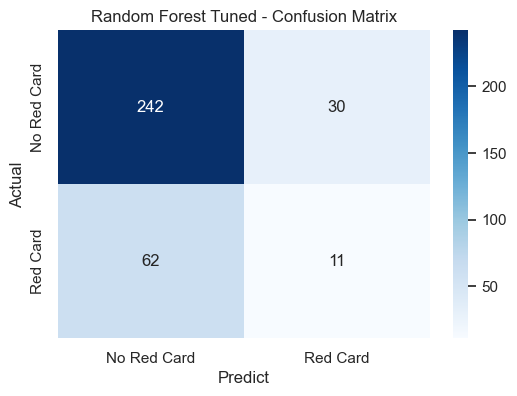

In [109]:
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf_tuned, annot= True, fmt='d', cmap='Blues',
            xticklabels=['No Red Card', 'Red Card'],
            yticklabels=['No Red Card', 'Red Card'],
            linewidth=0)
plt.title('Random Forest Tuned - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()

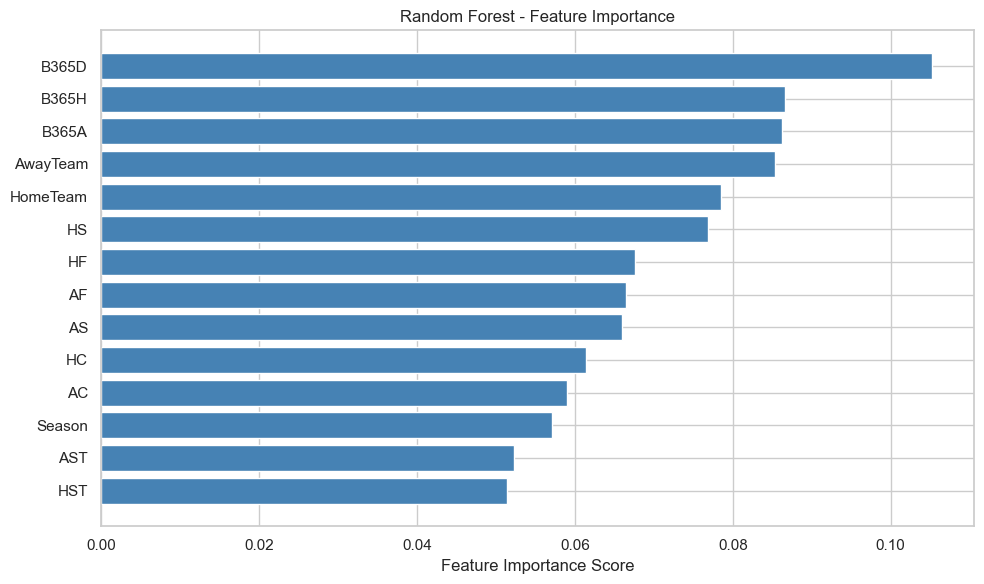

Feature Importances:
  B365D           : 0.1053
  B365H           : 0.0866
  B365A           : 0.0862
  AwayTeam        : 0.0854
  HomeTeam        : 0.0785
  HS              : 0.0769
  HF              : 0.0676
  AF              : 0.0665
  AS              : 0.0659
  HC              : 0.0614
  AC              : 0.0590
  Season          : 0.0571
  AST             : 0.0523
  HST             : 0.0514


In [110]:
# Get feature importances from best RF model
feature_names      = x_train_scaled.columns.tolist()
feature_importances = best_rf_model.feature_importances_

# Sort by importance
sorted_idx    = feature_importances.argsort()[::-1]
sorted_names  = [feature_names[i] for i in sorted_idx]
sorted_values = feature_importances[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_names[::-1], sorted_values[::-1], color='steelblue')
plt.xlabel('Feature Importance Score')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

# Print values
print('Feature Importances:')
for name, score in zip(sorted_names, sorted_values):
    print(f'  {name:<15} : {score:.4f}')

Model                            Accuracy  Precision     Recall         F1
KNN Base                           55.07%       0.68       0.55       0.59
KNN Tuned                          70.14%      0.694      0.701      0.698
Logistic Regression Base           51.01%      0.626      0.510      0.553
Logistic Regression Tuned          51.01%      0.626      0.510      0.553
Random Forest Base                 71.88%      0.671      0.719      0.691
Random Forest Tuned                73.33%      0.684      0.733      0.703


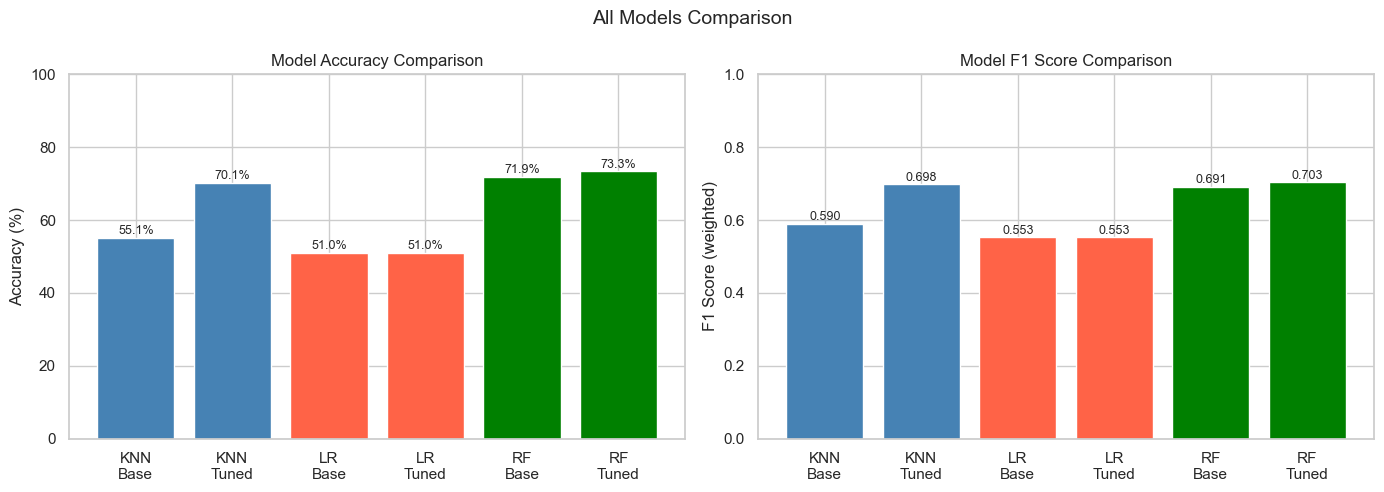

In [115]:
# Summary table of all models
print('=' * 65)
print(f"{'Model':<30} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('=' * 65)
print(f"{'KNN Base':<30} {'55.07%':>10} {'0.68':>10} {'0.55':>10} {'0.59':>10}")
print(f"{'KNN Tuned':<30} {'70.14%':>10} {'0.694':>10} {'0.701':>10} {'0.698':>10}")
print(f"{'Logistic Regression Base':<30} {'51.01%':>10} {'0.626':>10} {'0.510':>10} {'0.553':>10}")
print(f"{'Logistic Regression Tuned':<30} {'51.01%':>10} {'0.626':>10} {'0.510':>10} {'0.553':>10}")
print(f"{'Random Forest Base':<30} {'71.88%':>10} {'0.671':>10} {'0.719':>10} {'0.691':>10}")
print(f"{'Random Forest Tuned':<30} {str(round(rf_acc,2))+'%':>10} {str(round(rf_pre,3)):>10} {str(round(rf_recall,3)):>10} {str(round(rf_f1,3)):>10}")
print('=' * 65)

# Bar chart comparison
models     = ['KNN\nBase', 'KNN\nTuned', 'LR\nBase', 'LR\nTuned', 'RF\nBase', 'RF\nTuned']
accuracies = [55.07, 70.14, 51.01, 51.01, 71.88, rf_acc]
f1_scores  = [0.59, 0.698, 0.553, 0.553, 0.691, rf_f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].bar(models, accuracies, color=['steelblue', 'steelblue',
                                        'tomato', 'tomato',
                                        'green', 'green'])
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# F1 Score comparison
axes[1].bar(models, f1_scores, color=['steelblue', 'steelblue',
                                       'tomato', 'tomato',
                                       'green', 'green'])
axes[1].set_title('Model F1 Score Comparison')
axes[1].set_ylabel('F1 Score (weighted)')
axes[1].set_ylim(0, 1)
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('All Models Comparison', fontsize=14)
plt.tight_layout()
plt.show()

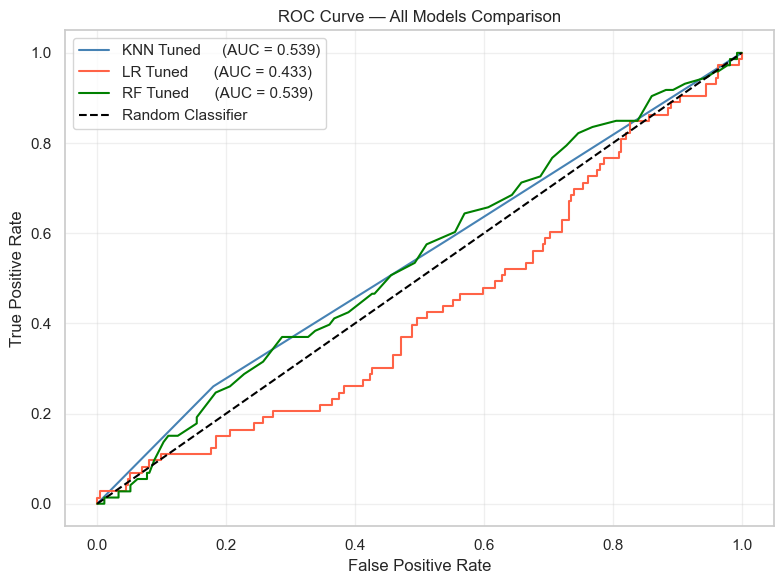

KNN Tuned  AUC : 0.539
LR Tuned   AUC : 0.433
RF Tuned   AUC : 0.539


In [112]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for each model
y_proba_knn = best_knn_model.predict_proba(x_test_scaled)[:, 1]
y_proba_lr  = best_lr_model.predict_proba(x_test_scaled)[:, 1]
y_proba_rf  = best_rf_model.predict_proba(x_test_scaled)[:, 1]

# Calculate ROC curves
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_proba_lr)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)

# AUC scores
auc_knn = roc_auc_score(y_test, y_proba_knn)
auc_lr  = roc_auc_score(y_test, y_proba_lr)
auc_rf  = roc_auc_score(y_test, y_proba_rf)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='steelblue', label=f'KNN Tuned     (AUC = {auc_knn:.3f})')
plt.plot(fpr_lr,  tpr_lr,  color='tomato',    label=f'LR Tuned      (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf,  tpr_rf,  color='green',     label=f'RF Tuned      (AUC = {auc_rf:.3f})')
plt.plot([0, 1],  [0, 1],  color='black', linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'KNN Tuned  AUC : {auc_knn:.3f}')
print(f'LR Tuned   AUC : {auc_lr:.3f}')
print(f'RF Tuned   AUC : {auc_rf:.3f}')